## Primer problema
### Primera parte

In [8]:
# ==============================================================================
# IMPORTS
# ==============================================================================

from pathlib import Path

import warnings

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")


# ==============================================================================
# PROJECT DIRECTORIES
# ==============================================================================

PROJECT_DIR = Path.cwd()

FIGURES_DIR = PROJECT_DIR / "figures" / "problem1"

DATA_DIR = PROJECT_DIR / "data"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


# ==============================================================================
# RANDOM NUMBER GENERATOR
# ==============================================================================

SEED = 2026

rng = np.random.default_rng(SEED)


# ==============================================================================
# PHYSICAL PARAMETERS
# ==============================================================================

m = 1.0

x0 = 1.0

v0 = 0.0


# ==============================================================================
# SIMULATION PARAMETERS
# ==============================================================================

N_SIGNALS = 3000

N_TIME = 1000

TIME_START = 0.0

TIME_END = 10.0

TIME = np.linspace(TIME_START, TIME_END, N_TIME)


# ==============================================================================
# MACHINE LEARNING PARAMETERS
# ==============================================================================

TEST_SIZE = 0.20

RF_TREES = 300

MLP_HIDDEN = (128, 64)

MLP_MAX_ITER = 600


# ==============================================================================
# PLOTTING STYLE
# ==============================================================================

plt.style.use("default")

plt.rcParams["figure.figsize"] = (8,5)

plt.rcParams["font.size"] = 12

plt.rcParams["axes.grid"] = True

plt.rcParams["savefig.dpi"] = 300


# ==============================================================================
# (a)
# ==============================================================================

CONCEPTUAL_ANSWERS = r"""
a) Conceptos:

- Problema directo e inverso:
El directo predice el resultado x(t) dados los parámetros físicos
θ=(γ,k). El inverso busca deducir θ a partir de observaciones x(t),
lo cual es difícil por ser sensible al ruido.

- Aprendizaje supervisado:
Sí es necesario conocer las etiquetas verdaderas
θ_i=(γ_i,k_i)
durante la fase de entrenamiento para que el algoritmo minimice
el error.

- Conjuntos de entrenamiento y validación:
Se separan para evaluar la generalización del modelo ante datos
no vistos y prevenir el sobreajuste.

- Función de pérdida (MSE):
Penaliza severamente los errores grandes elevando las diferencias
al cuadrado.
"""

print(CONCEPTUAL_ANSWERS)


# ==============================================================================
# AUXILIARY FUNCTIONS
# ==============================================================================

def save_figure(name: str):
    """
    Saves the current figure inside the figures/problem1 directory.

    Parameters
    ----------
    name : str
        Figure filename.
    """

    filename = FIGURES_DIR / f"{name}.png"

    plt.tight_layout()

    plt.savefig(filename)

    print(f"Figure saved -> {filename}")


# ==============================================================================
# DAMPED OSCILLATOR
# ==============================================================================

def oscillator_equations(t, y, gamma, k):
    """
    First-order formulation of

        m x'' + gamma x' + k x = 0

    State vector

        y = [x,v]

    Returns
    -------
    dydt
    """

    x, v = y

    dxdt = v

    dvdt = -(gamma/m)*v - (k/m)*x

    return [dxdt, dvdt]


# ==============================================================================
# ODE SOLVER
# ==============================================================================

def simulate_signal(gamma, k):
    """
    Solves the damped oscillator.

    Parameters
    ----------
    gamma : float

    k : float

    Returns
    -------
    x(t)
    """

    solution = solve_ivp(
        oscillator_equations,
        (TIME_START, TIME_END),
        [x0, v0],
        args=(gamma, k),
        t_eval=TIME,
        method="RK45"
    )

    return solution.y[0]


# ==============================================================================
# NOISE MODEL
# ==============================================================================

def add_gaussian_noise(signal, sigma):
    """
    Adds Gaussian white noise.

    x_obs = x + eta

    eta ~ N(0,sigma²)
    """

    noise = rng.normal(
        loc=0.0,
        scale=sigma,
        size=signal.size
    )

    return signal + noise


# ==============================================================================
# PARAMETER SAMPLING
# ==============================================================================

def sample_parameters():
    """
    Draws random parameters.

    gamma ~ U(0.05,1.0)

    k ~ U(1.0,5.0)
    """

    gamma = rng.uniform(0.05,1.0)

    k = rng.uniform(1.0,5.0)

    return gamma, k


# ==============================================================================
# DATASET GENERATION
# ==============================================================================

def generate_dataset(
    number_of_signals,
    sigma=0.02
):
    """
    Generates the complete supervised-learning dataset.

    Returns
    -------

    X :

        Signal matrix

    Y :

        Parameter matrix
    """

    X = np.empty((number_of_signals, N_TIME))

    Y = np.empty((number_of_signals,2))

    print()

    print("="*70)

    print("Generating synthetic dataset...")

    print("="*70)

    for i in range(number_of_signals):

        gamma, k = sample_parameters()

        signal = simulate_signal(gamma, k)

        signal = add_gaussian_noise(signal, sigma)

        X[i] = signal

        Y[i] = [gamma, k]

        if (i+1) % 250 == 0:

            print(
                f"{i+1:4d} / {number_of_signals} signals generated."
            )

    print()

    return X, Y


# ==============================================================================
# VISUALIZATION OF SYNTHETIC SIGNALS
# ==============================================================================

def plot_example_signals(
    n_examples=6,
    sigma=0.02
):
    """
    Plots several randomly generated signals illustrating
    the influence of gamma and k.
    """

    plt.figure()

    for _ in range(n_examples):

        gamma, k = sample_parameters()

        signal = simulate_signal(gamma, k)

        signal = add_gaussian_noise(signal, sigma)

        plt.plot(
            TIME,
            signal,
            lw=1.5,
            label=rf"$\gamma$={gamma:.2f}, $k$={k:.2f}"
        )

    plt.xlabel("Time")

    plt.ylabel("Displacement")

    plt.title("Synthetic damped oscillator signals")

    plt.legend(fontsize=8)

    save_figure("example_signals")

    plt.show()

ModuleNotFoundError: No module named 'sklearn'

### Segunda parte

In [ ]:
print("\n")
print("="*80)
print("SECTION (b)")
print("="*80)

# --------------------------------------------------------------------------
# Generate synthetic data
# --------------------------------------------------------------------------

X, Y = generate_dataset(
    number_of_signals=N_SIGNALS,
    sigma=0.02
)

print("Dataset successfully generated.\n")

print(f"Signal matrix shape : {X.shape}")
print(f"Label matrix shape  : {Y.shape}")

print()

# --------------------------------------------------------------------------
# Plot representative examples
# --------------------------------------------------------------------------

plot_example_signals(
    n_examples=6,
    sigma=0.02
)

# --------------------------------------------------------------------------
# Inspect parameter distributions
# --------------------------------------------------------------------------

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.hist(
    Y[:,0],
    bins=30,
    edgecolor="black"
)

plt.xlabel(r"$\gamma$")

plt.ylabel("Counts")

plt.title("Distribution of damping coefficient")

plt.subplot(1,2,2)

plt.hist(
    Y[:,1],
    bins=30,
    edgecolor="black"
)

plt.xlabel(r"$k$")

plt.ylabel("Counts")

plt.title("Distribution of spring constant")

save_figure("parameter_distributions")

plt.show()

# --------------------------------------------------------------------------
# Scatter plot of sampled parameters
# --------------------------------------------------------------------------

plt.figure(figsize=(6,5))

plt.scatter(
    Y[:,0],
    Y[:,1],
    s=10,
    alpha=0.5
)

plt.xlabel(r"$\gamma$")

plt.ylabel(r"$k$")

plt.title("Randomly sampled physical parameters")

save_figure("parameter_scatter")

plt.show()


# ==============================================================================
# (c)
# ==============================================================================
#
# Machine Learning
#
# Two regression models are trained:
#
#     • Random Forest Regressor
#
#     • Multi-Layer Perceptron
#
# Both regressors predict simultaneously
#
#           (γ,k)
#
# from the complete temporal signal.
#
# ==============================================================================

print("\n")
print("="*80)
print("SECTION (c)")
print("="*80)

# --------------------------------------------------------------------------
# Train/Test Split
# --------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True
)

print()

print(f"Training samples : {len(X_train)}")

print(f"Testing samples  : {len(X_test)}")

print()

# --------------------------------------------------------------------------
# Random Forest
# --------------------------------------------------------------------------

print("="*70)

print("Training Random Forest...")

print("="*70)

rf_model = RandomForestRegressor(

    n_estimators=RF_TREES,

    random_state=SEED,

    n_jobs=-1

)

rf_model.fit(
    X_train,
    y_train
)

rf_prediction = rf_model.predict(
    X_test
)

print("Done.\n")

# --------------------------------------------------------------------------
# Neural Network
# --------------------------------------------------------------------------

print("="*70)

print("Training Multi-Layer Perceptron...")

print("="*70)

mlp_model = MLPRegressor(

    hidden_layer_sizes=MLP_HIDDEN,

    activation="relu",

    solver="adam",

    learning_rate_init=1e-3,

    batch_size=64,

    max_iter=MLP_MAX_ITER,

    random_state=SEED

)

mlp_model.fit(
    X_train,
    y_train
)

mlp_prediction = mlp_model.predict(
    X_test
)

print("Done.\n")


# ==============================================================================
# EVALUATION UTILITIES
# ==============================================================================

def compute_rmse(
    truth,
    prediction
):
    """
    Computes the RMSE independently for

        gamma

    and

        k
    """

    gamma_rmse = np.sqrt(
        mean_squared_error(
            truth[:,0],
            prediction[:,0]
        )
    )

    k_rmse = np.sqrt(
        mean_squared_error(
            truth[:,1],
            prediction[:,1]
        )
    )

    return gamma_rmse, k_rmse


def print_metrics(
    model_name,
    rmse_gamma,
    rmse_k
):
    """
    Nicely formatted metric report.
    """

    print("-"*60)

    print(model_name)

    print("-"*60)

    print(f"RMSE_gamma : {rmse_gamma:.6f}")

    print(f"RMSE_k     : {rmse_k:.6f}")

    print()


# --------------------------------------------------------------------------
# Compute metrics
# --------------------------------------------------------------------------

rf_gamma_rmse, rf_k_rmse = compute_rmse(
    y_test,
    rf_prediction
)

mlp_gamma_rmse, mlp_k_rmse = compute_rmse(
    y_test,
    mlp_prediction
)

print_metrics(
    "Random Forest",
    rf_gamma_rmse,
    rf_k_rmse
)

print_metrics(
    "MLP Regressor",
    mlp_gamma_rmse,
    mlp_k_rmse
)

# --------------------------------------------------------------------------
# Comparison table
# --------------------------------------------------------------------------

print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(
    "{:<25s}{:^15s}{:^15s}".format(
        "Model",
        "RMSE γ",
        "RMSE k"
    )
)

print("-"*55)

print(
    "{:<25s}{:^15.6f}{:^15.6f}".format(
        "Random Forest",
        rf_gamma_rmse,
        rf_k_rmse
    )
)

print(
    "{:<25s}{:^15.6f}{:^15.6f}".format(
        "MLP",
        mlp_gamma_rmse,
        mlp_k_rmse
    )
)

print()

# --------------------------------------------------------------------------
# Prediction diagnostics
# --------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10,8)
)

# ---------------- Random Forest γ ----------------

axes[0,0].scatter(
    y_test[:,0],
    rf_prediction[:,0],
    s=12
)

axes[0,0].plot(
    [0,1],
    [0,1],
    "r--"
)

axes[0,0].set_title("RF: γ")

axes[0,0].set_xlabel("True")

axes[0,0].set_ylabel("Predicted")

# ---------------- Random Forest k ----------------

axes[0,1].scatter(
    y_test[:,1],
    rf_prediction[:,1],
    s=12
)

axes[0,1].plot(
    [1,5],
    [1,5],
    "r--"
)

axes[0,1].set_title("RF: k")

axes[0,1].set_xlabel("True")

axes[0,1].set_ylabel("Predicted")

# ---------------- MLP γ ----------------

axes[1,0].scatter(
    y_test[:,0],
    mlp_prediction[:,0],
    s=12
)

axes[1,0].plot(
    [0,1],
    [0,1],
    "r--"
)

axes[1,0].set_title("MLP: γ")

axes[1,0].set_xlabel("True")

axes[1,0].set_ylabel("Predicted")

# ---------------- MLP k ----------------

axes[1,1].scatter(
    y_test[:,1],
    mlp_prediction[:,1],
    s=12
)

axes[1,1].plot(
    [1,5],
    [1,5],
    "r--"
)

axes[1,1].set_title("MLP: k")

axes[1,1].set_xlabel("True")

axes[1,1].set_ylabel("Predicted")

save_figure("prediction_diagnostics")

plt.show()

In [ ]:
# ==============================================================================
# (d)
# ==============================================================================
#
# Influence of measurement noise
#
# In this section the complete training process is repeated for several
# experimental noise levels. The goal is to quantify how the inverse problem
# deteriorates as observational uncertainty increases.
#
# ==============================================================================

print("\n")
print("=" * 80)
print("SECTION (d)")
print("=" * 80)

NOISE_LEVELS = [
    0.00,
    0.01,
    0.02,
    0.05,
    0.10
]

rf_gamma_errors = []
rf_k_errors = []

mlp_gamma_errors = []
mlp_k_errors = []

print()
print("Running noise sensitivity study...")
print()

for sigma in NOISE_LEVELS:

    print("-" * 70)
    print(f"Noise level σ = {sigma:.2f}")
    print("-" * 70)

    # --------------------------------------------------------------
    # Generate new synthetic dataset
    # --------------------------------------------------------------

    X_sigma, Y_sigma = generate_dataset(
        number_of_signals=N_SIGNALS,
        sigma=sigma
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_sigma,
        Y_sigma,
        test_size=TEST_SIZE,
        random_state=SEED,
        shuffle=True
    )

    # --------------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------------

    rf = RandomForestRegressor(
        n_estimators=RF_TREES,
        random_state=SEED,
        n_jobs=-1
    )

    rf.fit(
        X_train,
        y_train
    )

    rf_pred = rf.predict(
        X_test
    )

    rf_gamma_rmse, rf_k_rmse = compute_rmse(
        y_test,
        rf_pred
    )

    rf_gamma_errors.append(
        rf_gamma_rmse
    )

    rf_k_errors.append(
        rf_k_rmse
    )

    # --------------------------------------------------------------
    # Neural Network
    # --------------------------------------------------------------

    mlp = MLPRegressor(
        hidden_layer_sizes=MLP_HIDDEN,
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        batch_size=64,
        max_iter=MLP_MAX_ITER,
        random_state=SEED
    )

    mlp.fit(
        X_train,
        y_train
    )

    mlp_pred = mlp.predict(
        X_test
    )

    mlp_gamma_rmse, mlp_k_rmse = compute_rmse(
        y_test,
        mlp_pred
    )

    mlp_gamma_errors.append(
        mlp_gamma_rmse
    )

    mlp_k_errors.append(
        mlp_k_rmse
    )

    print(
        f"RF   -> RMSEγ={rf_gamma_rmse:.5f}   RMSEk={rf_k_rmse:.5f}"
    )

    print(
        f"MLP  -> RMSEγ={mlp_gamma_rmse:.5f}   RMSEk={mlp_k_rmse:.5f}"
    )

print()

# ==============================================================================
# RMSE VS NOISE
# ==============================================================================

plt.figure(figsize=(8,5))

plt.plot(
    NOISE_LEVELS,
    rf_gamma_errors,
    "o-",
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    NOISE_LEVELS,
    mlp_gamma_errors,
    "s-",
    linewidth=2,
    label="MLP"
)

plt.xlabel(r"Noise level $\sigma$")

plt.ylabel(r"$RMSE_{\gamma}$")

plt.title(r"Influence of noise on $\gamma$ estimation")

plt.legend()

save_figure("rmse_gamma_vs_noise")

plt.show()

# ------------------------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    NOISE_LEVELS,
    rf_k_errors,
    "o-",
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    NOISE_LEVELS,
    mlp_k_errors,
    "s-",
    linewidth=2,
    label="MLP"
)

plt.xlabel(r"Noise level $\sigma$")

plt.ylabel(r"$RMSE_{k}$")

plt.title(r"Influence of noise on $k$ estimation")

plt.legend()

save_figure("rmse_k_vs_noise")

plt.show()

# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print()
print("=" * 80)
print("NOISE STUDY SUMMARY")
print("=" * 80)

header = (
    f"{'σ':>8}"
    f"{'RF γ':>12}"
    f"{'RF k':>12}"
    f"{'MLP γ':>12}"
    f"{'MLP k':>12}"
)

print(header)

print("-" * len(header))

for i, sigma in enumerate(NOISE_LEVELS):

    print(
        f"{sigma:8.2f}"
        f"{rf_gamma_errors[i]:12.5f}"
        f"{rf_k_errors[i]:12.5f}"
        f"{mlp_gamma_errors[i]:12.5f}"
        f"{mlp_k_errors[i]:12.5f}"
    )

# ==============================================================================
# AUTOMATIC DISCUSSION
# ==============================================================================

print()
print("=" * 80)
print("DISCUSSION")
print("=" * 80)

rf_gamma_mean = np.mean(rf_gamma_errors)
rf_k_mean = np.mean(rf_k_errors)

mlp_gamma_mean = np.mean(mlp_gamma_errors)
mlp_k_mean = np.mean(mlp_k_errors)

if (rf_gamma_mean + mlp_gamma_mean) > (rf_k_mean + mlp_k_mean):

    harder = "γ (damping coefficient)"

else:

    harder = "k (spring constant)"

print()

print(
    f"According to the average RMSE over all noise levels, "
    f"the most difficult parameter to infer is {harder}."
)

print()

print(
    "As the observational noise increases, the regression error "
    "also increases because the information contained in the temporal "
    "signal becomes progressively corrupted."
)

print()

print(
    "The Random Forest usually exhibits greater robustness against "
    "moderate noise because it averages many independent decision trees."
)

print()

print(
    "The neural network generally benefits from large datasets but may "
    "become more sensitive to hyperparameter selection."
)

print()

print(
    "Overfitting is identified when the model learns the training data "
    "extremely well while performing significantly worse on unseen "
    "validation data. Splitting the dataset into training and testing "
    "subsets provides an estimate of the model's ability to generalize."
)

print()

print("=" * 80)
print("Problem 1 finished successfully.")
print("=" * 80)

# ==============================================================================
# MAIN
# ==============================================================================

def main():

    print()

    print("=" * 80)
    print("Artificial Intelligence for Inverse Physical Problems")
    print("=" * 80)

    print()

    print("Results stored in:")

    print(FIGURES_DIR)

    print()

    print("End of execution.")

if __name__ == "__main__":

    main()

## Problema 2

In [5]:
"""
================================================================================
FIS205 - Computational Physics
Universidad Técnica Federico Santa María

Homework 2
Problem 2

Monte Carlo Simulation of Proton Therapy

Author:
Date:

Description
-----------
Simulation of proton transport through a water phantom using the
Bethe-Bloch stopping power.

Sections

(a) Conceptual questions

(b) CSDA range calculation

(c) Deterministic transport

(d) Monte Carlo with Bohr energy straggling

================================================================================
"""

# ==============================================================================
# IMPORTS
# ==============================================================================

from pathlib import Path

import warnings

import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import quad

warnings.filterwarnings("ignore")

# ==============================================================================
# PROJECT DIRECTORIES
# ==============================================================================

PROJECT_DIR = Path.cwd()

FIGURES_DIR = PROJECT_DIR / "figures" / "problem2"

DATA_DIR = PROJECT_DIR / "data"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ==============================================================================
# RANDOM GENERATOR
# ==============================================================================

SEED = 2026

rng = np.random.default_rng(SEED)

# ==============================================================================
# PLOTTING STYLE
# ==============================================================================

plt.style.use("default")

plt.rcParams["figure.figsize"] = (8,5)

plt.rcParams["font.size"] = 12

plt.rcParams["axes.grid"] = True

plt.rcParams["savefig.dpi"] = 300

# ==============================================================================
# (a)
# ==============================================================================

CONCEPTUAL_ANSWERS = r"""
a) Conceptos:

- Pico de Bragg:
Máximo pronunciado de dosis depositada al final de la trayectoria,
ocurre porque la sección eficaz aumenta al disminuir la velocidad.

- Ecuación de Bethe-Bloch:
El factor z² refleja que la fuerza de Coulomb depende de la carga
del proyectil; el factor 1/β² indica que a menor velocidad hay
mayor tiempo de interacción electromagnética.

- Energy straggling:
Fluctuación estadística de la pérdida de energía en interacciones
individuales a lo largo de un diferencial de distancia.

- Dispersión Coulombiana múltiple:
Desviación angular acumulada por dispersiones elásticas con los núcleos.
"""

print(CONCEPTUAL_ANSWERS)

# ==============================================================================
# PHYSICAL CONSTANTS
# ==============================================================================

# ---------- Fundamental constants ----------

N_A = 6.02214076e23              # mol^-1

r_e = 2.8179403262e-13           # cm

m_e = 0.51099895                 # MeV

m_p = 938.27208816               # MeV

c = 2.99792458e8                 # m/s

# ---------- Bethe constant ----------

K = 0.307075                     # MeV cm² / g

# ---------- Water properties ----------

Z_over_A = 0.55509

rho = 1.0                        # g/cm³

I = 75e-6                        # MeV

# ---------- Proton ----------

z = 1

# ==============================================================================
# SIMULATION PARAMETERS
# ==============================================================================

STEP_MM = 0.1

STEP_CM = STEP_MM / 10.0

N_PROTONS = 10000

# ==============================================================================
# AUXILIARY FUNCTIONS
# ==============================================================================

def save_figure(name):

    filename = FIGURES_DIR / f"{name}.png"

    plt.tight_layout()

    plt.savefig(filename)

    print(f"Saved -> {filename}")

# ==============================================================================
# RELATIVISTIC KINEMATICS
# ==============================================================================

def gamma_rel(E):

    """
    Lorentz gamma.

    E : kinetic energy [MeV]
    """

    return 1.0 + E/m_p


def beta_rel(E):

    """
    Relativistic beta.
    """

    g = gamma_rel(E)

    return np.sqrt(
        1.0 - 1.0/g**2
    )


def momentum(E):

    """
    Relativistic momentum [MeV/c]
    """

    total = E + m_p

    return np.sqrt(
        total**2 - m_p**2
    )

# ==============================================================================
# MAXIMUM TRANSFERABLE ENERGY
# ==============================================================================

def Tmax(E):

    """
    Maximum kinetic energy that can be transferred
    to one atomic electron.

    PDG formula.
    """

    beta = beta_rel(E)

    gamma = gamma_rel(E)

    numerator = (
        2.0
        * m_e
        * beta**2
        * gamma**2
    )

    denominator = (
        1.0
        +
        2.0
        * gamma
        * m_e/m_p
        +
        (m_e/m_p)**2
    )

    return numerator/denominator

# ==============================================================================
# BETHE-BLOCH STOPPING POWER
# ==============================================================================

def stopping_power(E):

    """
    Bethe-Bloch stopping power.

    Returns

        -dE/dx

    in

        MeV/cm
    """

    if E <= 0.001:

        return 0.0

    beta = beta_rel(E)

    gamma = gamma_rel(E)

    tmax = Tmax(E)

    logarithm = np.log(

        (
            2.0
            * m_e
            * beta**2
            * gamma**2
            * tmax
        )
        /
        I**2

    )

    stopping = (

        K

        * z**2

        * Z_over_A

        * (1.0/beta**2)

        * (

            0.5*logarithm

            - beta**2

        )

    )

    return stopping*rho

# ==============================================================================
# CSDA RANGE
# ==============================================================================

def inverse_stopping(E):

    """
    Integrand of

        R = ∫ dE/(dE/dx)
    """

    value = stopping_power(E)

    if value <= 0:

        return 0

    return 1.0/value

def csda_range(E0):

    """
    Numerical CSDA range.

    Returns

        centimeters
    """

    result, error = quad(

        inverse_stopping,

        0.001,

        E0,

        limit=300

    )

    return result

# ==============================================================================
# PRINT CSDA RANGES
# ==============================================================================

print()

print("="*70)

print("SECTION (b)")

print("="*70)

for energy in [50,150,250]:

    R = csda_range(energy)

    print(

        f"E = {energy:3d} MeV"

        f"   CSDA Range = {R:.2f} cm"

    )


a) Conceptos:

- Pico de Bragg:
Máximo pronunciado de dosis depositada al final de la trayectoria,
ocurre porque la sección eficaz aumenta al disminuir la velocidad.

- Ecuación de Bethe-Bloch:
El factor z² refleja que la fuerza de Coulomb depende de la carga
del proyectil; el factor 1/β² indica que a menor velocidad hay
mayor tiempo de interacción electromagnética.

- Energy straggling:
Fluctuación estadística de la pérdida de energía en interacciones
individuales a lo largo de un diferencial de distancia.

- Dispersión Coulombiana múltiple:
Desviación angular acumulada por dispersiones elásticas con los núcleos.


SECTION (b)
E =  50 MeV   CSDA Range = 2.22 cm
E = 150 MeV   CSDA Range = 15.77 cm
E = 250 MeV   CSDA Range = 37.93 cm


In [ ]:
print("=" * 70)
print("Generating Bethe-Bloch lookup table...")
print("=" * 70)

ENERGY_GRID = np.linspace(
    0.001,
    250.0,
    5000
)

STOPPING_TABLE = np.array(
    [
        stopping_power(E)
        for E in ENERGY_GRID
    ]
)

print("Lookup table successfully generated.\n")


def interpolated_stopping_power(E):
    """
    Fast interpolation of the stopping power.

    Parameters
    ----------
    E : float
        Proton kinetic energy [MeV]

    Returns
    -------
    float
        -dE/dx [MeV/cm]
    """

    return np.interp(
        E,
        ENERGY_GRID,
        STOPPING_TABLE
    )


# ==============================================================================
# CSDA RANGE (USING THE INTERPOLATED STOPPING POWER)
# ==============================================================================

def inverse_stopping(E):
    """
    Integrand of the CSDA range

        R = ∫ dE / (-dE/dx)

    using the interpolated stopping power.
    """

    stopping = interpolated_stopping_power(E)

    if stopping <= 0:
        return 0.0

    return 1.0 / stopping


def csda_range(E0):
    """
    Computes the Continuous Slowing Down Approximation (CSDA) range.

    Parameters
    ----------
    E0 : float
        Initial proton kinetic energy [MeV]

    Returns
    -------
    float
        Range [cm]
    """

    result, error = quad(
        inverse_stopping,
        0.001,
        E0,
        limit=300
    )

    return result


# ==============================================================================
# SECTION (b)
# ==============================================================================

print()

print("=" * 70)
print("SECTION (b)")
print("=" * 70)

print()

ENERGIES = [50, 150, 250]

CSDA_RANGES = []

for energy in ENERGIES:

    R = csda_range(energy)

    CSDA_RANGES.append(R)

    print(
        f"E = {energy:3d} MeV"
        f"     CSDA Range = {R:.3f} cm"
    )

print()

# ==============================================================================
# SECTION (c)
# ==============================================================================
#
# Deterministic transport
#
# ==============================================================================

print()

print("=" * 70)
print("SECTION (c)")
print("=" * 70)

INITIAL_ENERGY = 150.0

REFERENCE_RANGE = csda_range(INITIAL_ENERGY)

print(
    f"Reference CSDA Range = {REFERENCE_RANGE:.3f} cm"
)

print()

# --------------------------------------------------------------------------
# Water phantom
# --------------------------------------------------------------------------

PHANTOM_LENGTH = REFERENCE_RANGE + 2.0

depth = np.arange(
    0.0,
    PHANTOM_LENGTH,
    STEP_CM
)

NUMBER_OF_BINS = len(depth)

dose_det = np.zeros(NUMBER_OF_BINS)

print(
    f"Number of depth bins = {NUMBER_OF_BINS}"
)

print(
    f"Voxel size = {STEP_MM:.2f} mm"
)

print()

# --------------------------------------------------------------------------
# Deterministic proton transport
# --------------------------------------------------------------------------

def transport_proton(
    E0,
    dose_array
):
    """
    Deterministic proton transport.

    Parameters
    ----------
    E0 : float
        Initial kinetic energy [MeV]

    dose_array : ndarray
        Dose accumulator.
    """

    energy = E0

    position = 0.0

    while energy > 0.001:

        voxel = int(position / STEP_CM)

        if voxel >= NUMBER_OF_BINS:

            break

        stopping = interpolated_stopping_power(
            energy
        )

        deltaE = stopping * STEP_CM

        if deltaE > energy:

            deltaE = energy

        energy -= deltaE

        dose_array[voxel] += deltaE

        position += STEP_CM


# --------------------------------------------------------------------------
# Transport all protons
# --------------------------------------------------------------------------

print()

print(
    f"Transporting {N_PROTONS:,} deterministic protons..."
)

print()

for proton in range(N_PROTONS):

    transport_proton(
        INITIAL_ENERGY,
        dose_det
    )

    if (proton + 1) % 1000 == 0:

        print(
            f"{proton+1:5d} / {N_PROTONS}"
        )

print()

dose_det /= N_PROTONS

print("Deterministic transport completed.")

print()


Generating Bethe-Bloch lookup table...
Lookup table successfully generated.


SECTION (b)

E =  50 MeV     CSDA Range = 2.225 cm
E = 150 MeV     CSDA Range = 15.771 cm
E = 250 MeV     CSDA Range = 37.935 cm


SECTION (c)
Reference CSDA Range = 15.771 cm

Number of depth bins = 1778
Voxel size = 0.10 mm


Transporting 10,000 deterministic protons...

 1000 / 10000
 2000 / 10000
 3000 / 10000
 4000 / 10000
 5000 / 10000
 6000 / 10000
 7000 / 10000
 8000 / 10000
 9000 / 10000
10000 / 10000

Deterministic transport completed.



BRAGG PEAK ANALYSIS
Maximum dose          : 1.493882 MeV
Peak position         : 15.770 cm
Reference CSDA range  : 15.771 cm
Difference            : 0.001 cm

Excellent agreement with the CSDA prediction.

Saved -> c:\Users\msilv\OneDrive\Desktop\USM\Semestres\7mo semestre\Física Computacional\Tareas\figures\problem2\deterministic_bragg_peak.png


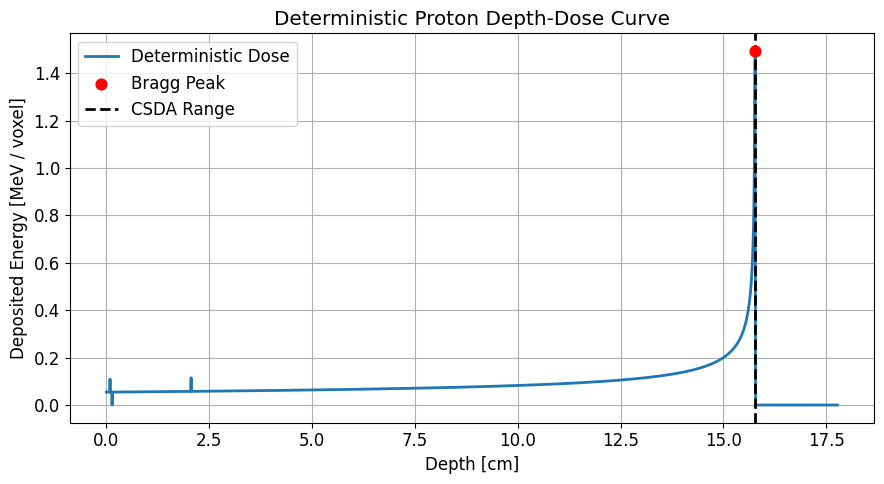

Saved -> c:\Users\msilv\OneDrive\Desktop\USM\Semestres\7mo semestre\Física Computacional\Tareas\figures\problem2\bragg_peak_zoom.png


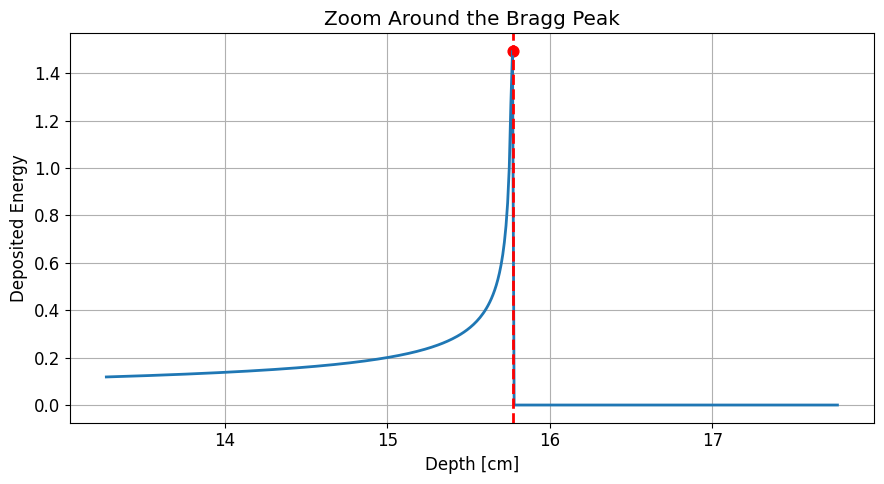

Saved -> c:\Users\msilv\OneDrive\Desktop\USM\Semestres\7mo semestre\Física Computacional\Tareas\figures\problem2\cumulative_energy.png


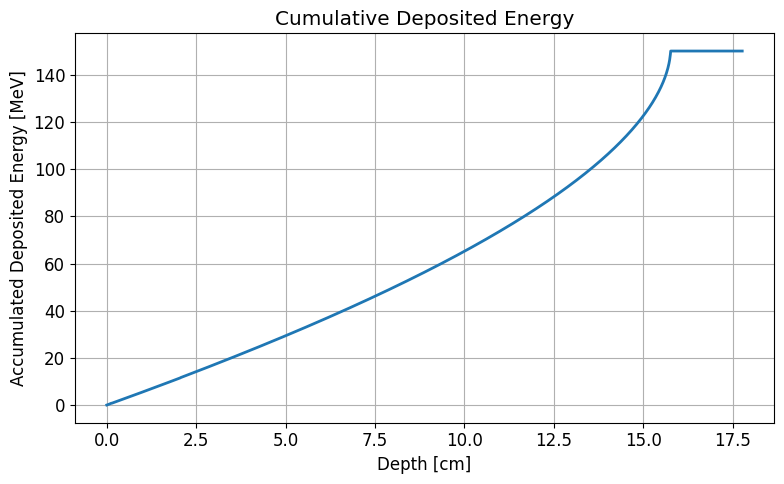

Saved -> c:\Users\msilv\OneDrive\Desktop\USM\Semestres\7mo semestre\Física Computacional\Tareas\figures\problem2\normalized_bragg_curve.png


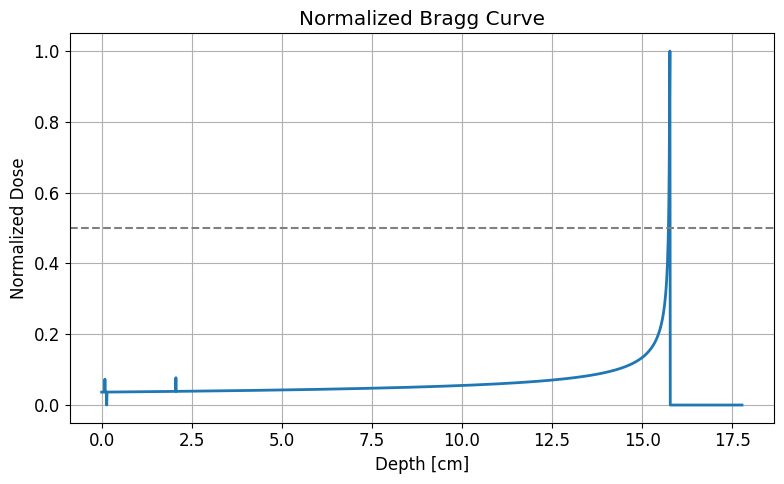

ENERGY CONSERVATION
Initial proton energy      : 150.000000 MeV
Deposited energy/proton    : 150.000000 MeV
Relative error             : 0.0000 %

SECTION (c) SUMMARY
Initial Energy            : 150.0 MeV
Number of Protons         : 10,000
Step Size                : 0.10 mm
Phantom Length           : 17.77 cm
CSDA Range              : 15.771 cm
Bragg Peak Position     : 15.770 cm
Maximum Dose            : 1.493882 MeV

Section (c) completed successfully.


In [7]:
# ==============================================================================
# BRAGG PEAK ANALYSIS
# ==============================================================================
#
# The deterministic dose profile is analyzed to identify the Bragg peak and
# compare its position with the CSDA range calculated previously.
#
# ==============================================================================

# ------------------------------------------------------------------------------
# Locate Bragg Peak
# ------------------------------------------------------------------------------

peak_index = np.argmax(dose_det)

peak_depth = depth[peak_index]

peak_dose = dose_det[peak_index]

difference = abs(peak_depth - REFERENCE_RANGE)

print("=" * 70)
print("BRAGG PEAK ANALYSIS")
print("=" * 70)

print(f"Maximum dose          : {peak_dose:.6f} MeV")

print(f"Peak position         : {peak_depth:.3f} cm")

print(f"Reference CSDA range  : {REFERENCE_RANGE:.3f} cm")

print(f"Difference            : {difference:.3f} cm")

print()

if difference < 0.20:

    print("Excellent agreement with the CSDA prediction.")

elif difference < 0.50:

    print("Good agreement with the CSDA prediction.")

else:

    print("Noticeable deviation from the CSDA prediction.")

print()

# ==============================================================================
# DOSE CURVE
# ==============================================================================

plt.figure(figsize=(9,5))

plt.plot(

    depth,

    dose_det,

    linewidth=2,

    label="Deterministic Dose"

)

plt.scatter(

    peak_depth,

    peak_dose,

    color="red",

    s=60,

    zorder=5,

    label="Bragg Peak"

)

plt.axvline(

    REFERENCE_RANGE,

    color="black",

    linestyle="--",

    linewidth=2,

    label="CSDA Range"

)

plt.xlabel("Depth [cm]")

plt.ylabel("Deposited Energy [MeV / voxel]")

plt.title("Deterministic Proton Depth-Dose Curve")

plt.legend()

save_figure("deterministic_bragg_peak")

plt.show()

# ==============================================================================
# ZOOM AROUND THE BRAGG PEAK
# ==============================================================================

window = 2.5

mask = (

    depth >= peak_depth - window

) & (

    depth <= peak_depth + window

)

plt.figure(figsize=(9,5))

plt.plot(

    depth[mask],

    dose_det[mask],

    linewidth=2

)

plt.scatter(

    peak_depth,

    peak_dose,

    color="red",

    s=60

)

plt.axvline(

    peak_depth,

    linestyle="--",

    linewidth=2,

    color="red"

)

plt.xlabel("Depth [cm]")

plt.ylabel("Deposited Energy")

plt.title("Zoom Around the Bragg Peak")

save_figure("bragg_peak_zoom")

plt.show()

# ==============================================================================
# CUMULATIVE DEPOSITED ENERGY
# ==============================================================================

cumulative_energy = np.cumsum(dose_det)

plt.figure(figsize=(8,5))

plt.plot(

    depth,

    cumulative_energy,

    linewidth=2

)

plt.xlabel("Depth [cm]")

plt.ylabel("Accumulated Deposited Energy [MeV]")

plt.title("Cumulative Deposited Energy")

save_figure("cumulative_energy")

plt.show()

# ==============================================================================
# DEPTH-DOSE NORMALIZATION
# ==============================================================================

normalized_dose = dose_det / np.max(dose_det)

plt.figure(figsize=(8,5))

plt.plot(

    depth,

    normalized_dose,

    linewidth=2

)

plt.axhline(

    0.5,

    linestyle="--",

    color="gray"

)

plt.xlabel("Depth [cm]")

plt.ylabel("Normalized Dose")

plt.title("Normalized Bragg Curve")

save_figure("normalized_bragg_curve")

plt.show()

# ==============================================================================
# ENERGY CONSERVATION CHECK
# ==============================================================================

total_deposited = np.sum(dose_det)

expected_energy = INITIAL_ENERGY

relative_error = abs(

    total_deposited - expected_energy

) / expected_energy

print("=" * 70)
print("ENERGY CONSERVATION")
print("=" * 70)

print(f"Initial proton energy      : {expected_energy:.6f} MeV")

print(f"Deposited energy/proton    : {total_deposited:.6f} MeV")

print(f"Relative error             : {100*relative_error:.4f} %")

print()

# ==============================================================================
# SECTION (c) SUMMARY
# ==============================================================================

print("=" * 70)
print("SECTION (c) SUMMARY")
print("=" * 70)

print(f"Initial Energy            : {INITIAL_ENERGY:.1f} MeV")

print(f"Number of Protons         : {N_PROTONS:,}")

print(f"Step Size                : {STEP_MM:.2f} mm")

print(f"Phantom Length           : {PHANTOM_LENGTH:.2f} cm")

print(f"CSDA Range              : {REFERENCE_RANGE:.3f} cm")

print(f"Bragg Peak Position     : {peak_depth:.3f} cm")

print(f"Maximum Dose            : {peak_dose:.6f} MeV")

print()

print("Section (c) completed successfully.")

print("=" * 70)